In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.holtwinters import ExponentialSmoothing

## Data Loading and Minor Preprocessing

In [2]:

# Load the data
file_path = 'transactions.csv'
data = pd.read_csv(file_path)

# Display basic information about the dataset
print('Dataset Overview:')
data.info()

data['date'] = pd.to_datetime(data['date'], dayfirst=True)
data['registration_date'] = pd.to_datetime(data['registration_date'], dayfirst=True)
data['first_deposit_date'] = pd.to_datetime(data['first_deposit_date'], dayfirst=True)
data['first_bet_date'] = pd.to_datetime(data['first_bet_date'], dayfirst=True)

Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 435749 entries, 0 to 435748
Data columns (total 22 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   userid               435749 non-null  int64  
 1   date                 435749 non-null  object 
 2   brand                435749 non-null  object 
 3   acquisition_channel  435749 non-null  object 
 4   CPA                  435749 non-null  float64
 5   country              435749 non-null  object 
 6   DOB                  435749 non-null  object 
 7   is_blocked           435749 non-null  bool   
 8   block_date           2218 non-null    object 
 9   registration_date    435749 non-null  object 
 10  first_deposit_date   435749 non-null  object 
 11  first_bet_date       435749 non-null  object 
 12  deposit_count        435749 non-null  int64  
 13  deposit_amount       435749 non-null  float64
 14  withdrawal_count     435749 non-null  int64  
 15 

# A/B Testing
## Comparing Average Deposit Amounts between Brands

In [3]:
brand_a = data[data['brand'] == 'Brand A']['deposit_amount'].astype(float)
brand_b = data[data['brand'] == 'Brand B']['deposit_amount'].astype(float)
t_stat, p_value = stats.ttest_ind(brand_a, brand_b, nan_policy='omit')
print(f'AB Test Results - T-Statistic: {t_stat}, P-Value: {p_value}')

AB Test Results - T-Statistic: -9.181244922034503, P-Value: 4.2791769535335985e-20


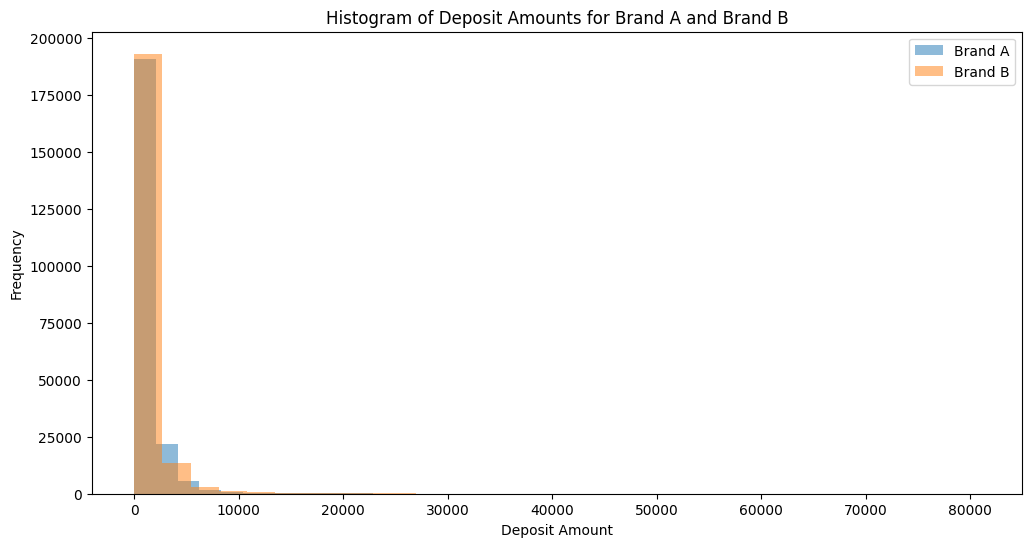

In [12]:
plt.figure(figsize=(12, 6))
plt.hist(brand_a, bins=30, alpha=0.5, label='Brand A')
plt.hist(brand_b, bins=30, alpha=0.5, label='Brand B')
plt.title('Histogram of Deposit Amounts for Brand A and Brand B')
plt.xlabel('Deposit Amount')
plt.ylabel('Frequency')
plt.legend()
plt.show()



The result indicates a significant difference between the two brands (P-Value: `4.2791769535335985e-20`), suggesting that the average deposit amounts are statistically different.

# Forecasting
## Forecasting Total Deposits using Exponential Smoothing

In [4]:
monthly_deposits = data.groupby(data['date'].dt.to_period('M'))['deposit_amount'].sum().astype(float)
model = ExponentialSmoothing(monthly_deposits, trend='add', seasonal='add', seasonal_periods=12).fit()
forecast = model.forecast(steps=6)
print('Forecast for Next 6 Months:')
print(forecast)

Forecast for Next 6 Months:
2025-02    5.884561e+06
2025-03    5.313053e+06
2025-04    2.571282e+06
2025-05    1.381788e+06
2025-06   -7.018188e+05
2025-07   -4.149144e+06
Freq: M, dtype: float64


/Users/unknown_/Desktop/workspace/igaming-analytics/.venv/lib/python3.9/site-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


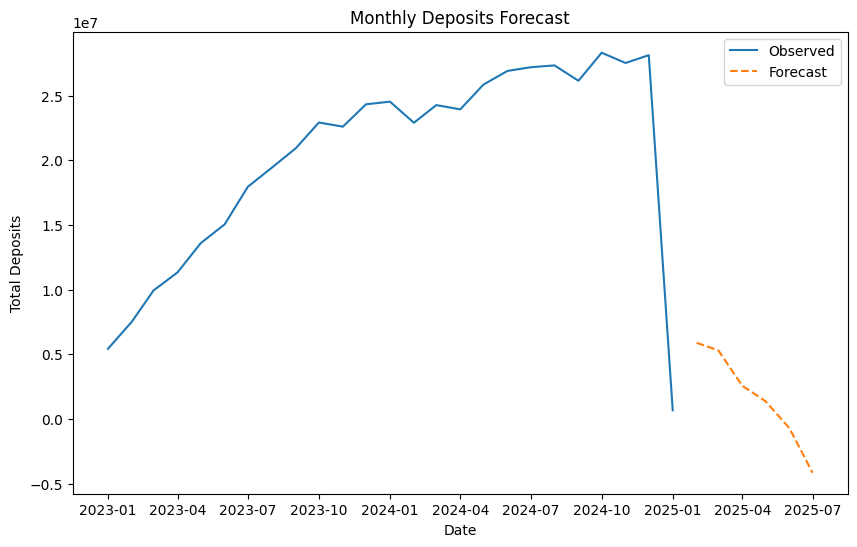

In [5]:
plt.figure(figsize=(10, 6))
plt.plot(monthly_deposits.index.to_timestamp(), monthly_deposits, label='Observed')
plt.plot(forecast.index.to_timestamp(), forecast, label='Forecast', linestyle='--')
plt.xlabel('Date')
plt.ylabel('Total Deposits')
plt.title('Monthly Deposits Forecast')
plt.legend()
plt.show()

The forecast shows a declining trend in deposits, with negative values predicted for the last two months. This might indicate a need to re-evaluate the model or consider external factors affecting deposits.


# Value Segmentation
## Using KMeans Clustering to Segment Users

In [6]:
segmentation_data = data[['deposit_amount', 'withdrawal_amount', 'bet_amount', 'win_amount']].fillna(0).astype(float)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(segmentation_data)
kmeans = KMeans(n_clusters=4, random_state=42).fit(scaled_data)
data['segment'] = kmeans.labels_
print('User Segmentation Completed. Segments:', data['segment'].unique())

User Segmentation Completed. Segments: [0 2 3 1]


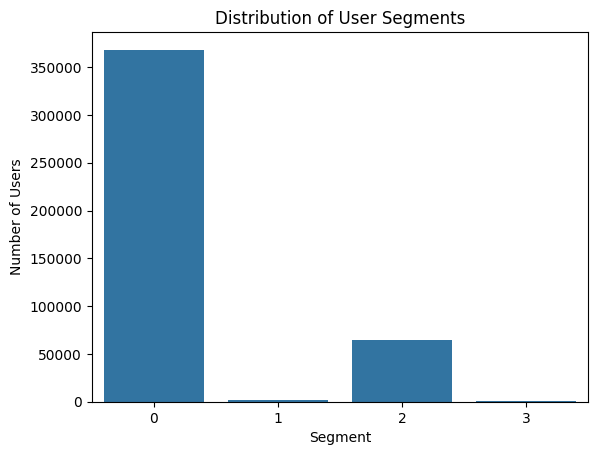

In [7]:
sns.countplot(x='segment', data=data)
plt.title('Distribution of User Segments')
plt.xlabel('Segment')
plt.ylabel('Number of Users')
plt.show()


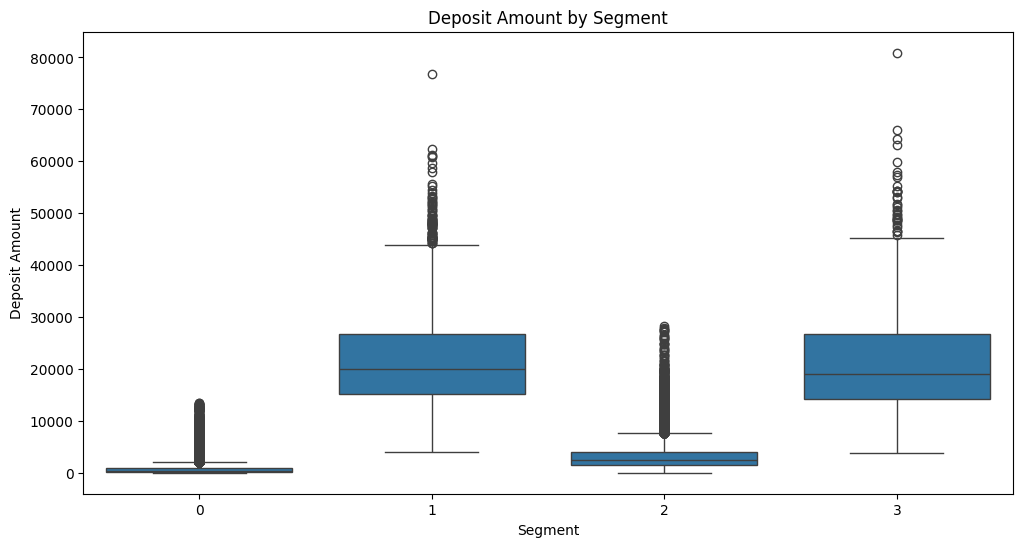

In [8]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='segment', y='deposit_amount', data=data)
plt.title('Deposit Amount by Segment')
plt.xlabel('Segment')
plt.ylabel('Deposit Amount')
plt.show()

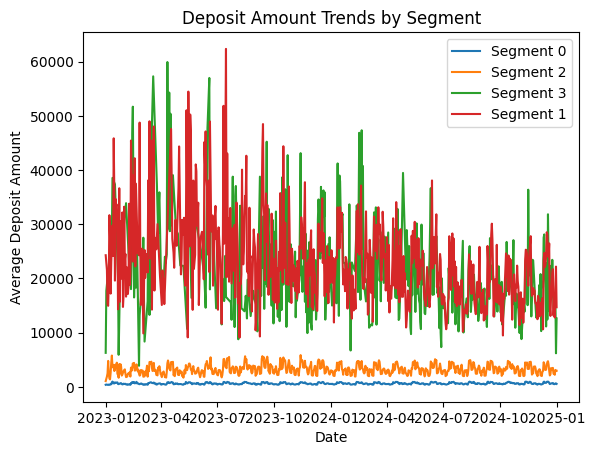

In [10]:
for segment in data['segment'].unique():
    subset = data[data['segment'] == segment]
    plt.plot(subset.groupby('date')['deposit_amount'].mean(), label=f'Segment {segment}')

plt.title('Deposit Amount Trends by Segment')
plt.xlabel('Date')
plt.ylabel('Average Deposit Amount')
plt.legend()
plt.show()
